check cuda config

In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(f"[{i}] {torch.cuda.get_device_name(i)}")

print(torch.__version__)
print("Hi!!!")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"

CUDA available: True
GPU count: 2
[0] Tesla T4
[1] Tesla T4
2.10.0+cu128
Hi!!!


In [2]:
import os
import math
import random
from collections import OrderedDict
from typing import Any, Optional, Tuple
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchaudio
from tqdm.auto import tqdm
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from sklearn import metrics
from torch.utils.data import DataLoader

configurations

In [3]:
# Optional (nice for shapes):
try:
    from torchinfo import summary
    HAS_TORCHINFO = True
except Exception:
    HAS_TORCHINFO = False

save_path = r"/kaggle/working/best_cm_model_rawformer.pth"
# ------------------ Configurable Paths ------------------ #
class SysConfig:
    """
    Folder-based dataset structure.
    Each split (train/dev/test) contains two subfolders: bonafide and spoof.
    """
    path_train =r"/kaggle/input/datasets/artharking/asv-19-aa/ASV19/train"
    path_dev   = r"/kaggle/input/datasets/artharking/asv-19-aa/ASV19/dev"
    path_test  =r"/kaggle/input/datasets/artharking/asv-19-aa/ASV19/test"


# ------------------ Experiment Hyperparameters ------------------ #
class ExpConfig:
    # Audio processing
    sample_rate = 16000
    pre_emphasis = 0.97
    train_duration_sec = 2
    test_duration_sec = 2

    # Model
    transformer_hidden = 660

    # Training hyperparameters
    batch_size = 32
    lr = 8*1e-4
    epochs = 5  # increase as needed

sys_cfg = SysConfig()
exp_cfg = ExpConfig()

initialize data augmentation

In [4]:
try:
    from torch_audiomentations import (
        Compose, AddColoredNoise, HighPassFilter, LowPassFilter, Gain
    )
    HAS_TA = True
except Exception:
    HAS_TA = False
    Compose = AddColoredNoise = HighPassFilter = LowPassFilter = Gain = None

class WaveformAugmentation(nn.Module):
    def __init__(self, aug_list=('ACN', 'HPF', 'LPF', 'GAN'), sr=16000):
        super().__init__()
        self.sr = sr
        if HAS_TA:
            transforms = []
            if 'ACN' in aug_list:
                transforms.append(AddColoredNoise(10, 40, -2.0, 2.0, p=0.5))
            if 'HPF' in aug_list:
                transforms.append(HighPassFilter(20.0, 2400.0, p=0.5))
            if 'LPF' in aug_list:
                transforms.append(LowPassFilter(150.0, 7500.0, p=0.5))
            if 'GAN' in aug_list:
                transforms.append(Gain(-15.0, 5.0, p=0.5))
            self.apply_augmentation = Compose(transforms) if transforms else None
        else:
            # No-op if torch_audiomentations isn't available
            self.apply_augmentation = None

    def forward(self, wav: torch.Tensor) -> torch.Tensor:
        # wav: (B, T)
        if self.apply_augmentation is None:
            return wav
        return self.apply_augmentation(wav.unsqueeze(1), self.sr).squeeze(1)


define dataloader

In [5]:
# ============================================================
# SIMPLE DATASET
# ============================================================

import soundfile as sf

class ASVspoofFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, sample_rate=16000, duration_sec=4):
        self.root_dir = root_dir
        self.sample_rate = sample_rate
        self.duration_sec = duration_sec
        self.audio_paths = []
        self.labels = []

        for label_name, label_value in [("bonafide", 1), ("spoof", 0)]:
            class_dir = os.path.join(root_dir, label_name)
            if os.path.exists(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith(".flac") or file.endswith(".wav"):
                        self.audio_paths.append(os.path.join(class_dir, file))
                        self.labels.append(label_value)

        print(f"📁 Loaded {len(self.audio_paths)} files from {root_dir}")

    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        path = self.audio_paths[idx]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        # --- Use soundfile for FLAC ---
        if path.lower().endswith(".flac"):
            wav_np, sr = sf.read(path)         # numpy array (T,) or (T, C)
            if wav_np.ndim > 1:                # convert stereo → mono
                wav_np = wav_np.mean(axis=1)
            wav = torch.tensor(wav_np, dtype=torch.float32).unsqueeze(0)  # [1, T]

        # --- Use torchaudio for WAV ---
        else:
            wav, sr = torchaudio.load(path)

        # --- Resample if needed ---
        if sr != self.sample_rate:
            wav = torchaudio.functional.resample(wav, sr, self.sample_rate)

        # --- Crop/pad ---
        num_samples = int(self.sample_rate * self.duration_sec)

        if wav.size(1) > num_samples:
            start = random.randint(0, wav.size(1) - num_samples)
            wav = wav[:, start:start + num_samples]
        elif wav.size(1) < num_samples:
            wav = F.pad(wav, (0, num_samples - wav.size(1)))

        return wav.squeeze(0), label

In [6]:
train_ds = ASVspoofFolderDataset(sys_cfg.path_train, exp_cfg.sample_rate, exp_cfg.train_duration_sec)
val_ds   = ASVspoofFolderDataset(sys_cfg.path_dev, exp_cfg.sample_rate, exp_cfg.test_duration_sec)
test_ds  = ASVspoofFolderDataset(sys_cfg.path_test, exp_cfg.sample_rate, exp_cfg.test_duration_sec)


📁 Loaded 25380 files from /kaggle/input/datasets/artharking/asv-19-aa/ASV19/train
📁 Loaded 24844 files from /kaggle/input/datasets/artharking/asv-19-aa/ASV19/dev
📁 Loaded 71237 files from /kaggle/input/datasets/artharking/asv-19-aa/ASV19/test


shuffel dataset 

In [7]:
train_loader = DataLoader(train_ds, batch_size=exp_cfg.batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=exp_cfg.batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=exp_cfg.batch_size, shuffle=False, num_workers=0)


initialize pre emphasizing

In [8]:
class PreEmphasis(nn.Module):
    def __init__(self, pre_emphasis: float = 0.97):
        super().__init__()
        # Conv1D filter shape: (out_channels=1, in_channels=1, kernel_size=2)
        filt = torch.tensor([[-pre_emphasis, 1.0]], dtype=torch.float32).unsqueeze(0)
        self.register_buffer("filter", filt)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T)
        x = x.unsqueeze(1)  # (B,1,T)
        x = F.pad(x, (1, 0), mode="reflect")
        x = F.conv1d(x, self.filter)
        return x.squeeze(1)  # (B,T)


In [9]:
pre = PreEmphasis(exp_cfg.pre_emphasis).to(DEVICE)

sincconv

In [10]:
class SincConv(nn.Module):
    """
    Adapted from AASIST. One input channel only.
    """
    @staticmethod
    def to_mel(hz): return 2595 * np.log10(1 + hz / 700)
    @staticmethod
    def to_hz(mel): return 700 * (10**(mel / 2595) - 1)

    def __init__(self, out_channels, kernel_size, sample_rate=16000, in_channels=1, stride=1, padding=0, dilation=1):
        super().__init__()
        if in_channels != 1:
            raise ValueError("SincConv supports only one input channel.")
        self.out_channels = out_channels
        self.sample_rate = sample_rate
        self.kernel_size = kernel_size + (kernel_size % 2 == 0)

        self.stride = stride
        self.padding = padding
        self.dilation = dilation

        NFFT = 512
        f = int(sample_rate / 2) * np.linspace(0, 1, int(NFFT / 2) + 1)
        fmel = self.to_mel(f)
        filbandwidthsmel = np.linspace(fmel.min(), fmel.max(), out_channels + 1)
        filbandwidthsf = self.to_hz(filbandwidthsmel)

        self.hsupp = torch.arange(-(self.kernel_size - 1) / 2,
                                  (self.kernel_size - 1) / 2 + 1)

        band_pass = torch.zeros(out_channels, self.kernel_size)
        for i in range(out_channels):
            fmin, fmax = filbandwidthsf[i], filbandwidthsf[i + 1]
            hHigh = (2 * fmax / sample_rate) * np.sinc(2 * fmax * self.hsupp / sample_rate)
            hLow  = (2 * fmin / sample_rate) * np.sinc(2 * fmin * self.hsupp / sample_rate)
            hideal = hHigh - hLow
            band_pass[i, :] = torch.tensor(np.hamming(self.kernel_size)) * torch.tensor(hideal)
        self.register_buffer("band_pass", band_pass)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B,1,T)
        filt = self.band_pass.to(x.device).view(self.out_channels, 1, self.kernel_size)
        return F.conv1d(x, filt, stride=self.stride, padding=self.padding, dilation=self.dilation, groups=1)


conv_2D_S_Block

In [11]:
class Conv2DBlock_S(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, is_first_block: bool = False):
        super().__init__()

        # ---- optional normaliser (BN+SELU) ----
        self.normalizer = None
        if not is_first_block:
            self.normalizer = nn.Sequential(
                nn.BatchNorm2d(in_channels),
                nn.SELU(inplace=True),
            )

        # ---- two conv layers + BN+SELU ----
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=(2, 5), padding=(1, 2)),
            nn.BatchNorm2d(out_channels),
            nn.SELU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=(2, 3), padding=(0, 1)),
        )

        # ---- residual connection when channel count changes ----
        self.downsampler = None
        if in_channels != out_channels:
            self.downsampler = nn.Conv2d(in_channels, out_channels,
                                        kernel_size=(1, 3), padding=(0, 1))

        self.pooling = nn.MaxPool2d(kernel_size=(1, 6))

    def forward(self, x):
        identity = x
        if self.downsampler is not None:
            identity = self.downsampler(identity)

        if self.normalizer is not None:
            x = self.normalizer(x)

        x = self.layers(x) + identity
        x = self.pooling(x)
        return x


Frontend S

In [12]:
class Frontend_S(nn.Module):
    def __init__(self, device, sinc_kernel_size=128, sample_rate=16000):
        super().__init__()

        # ---- Sinc layer (no parameters → safe on any device) ----
        self.sinc_layer = SincConv(
            in_channels=1,
            out_channels=70,
            kernel_size=sinc_kernel_size,
            sample_rate=sample_rate,
        )

        # ---- BatchNorm that must live on the target device ----
        self.bn = nn.BatchNorm2d(num_features=1).to(device)

        self.selu = nn.SELU(inplace=True)

        # ---- Conv blocks (they also contain BatchNorms) ----
        self.conv_blocks = nn.Sequential(
            Conv2DBlock_S(in_channels=1,  out_channels=32, is_first_block=True),
            Conv2DBlock_S(in_channels=32, out_channels=32),
            Conv2DBlock_S(in_channels=32, out_channels=64),
            Conv2DBlock_S(in_channels=64, out_channels=64),
        ).to(device)                     # <-- move the whole Sequential

    def forward(self, x):
        # x : [B, T]  (raw waveform)
        x = x.unsqueeze(1)                     # [B,1,T]
        x = self.sinc_layer(x)                 # [B,70,T']
        x = x.unsqueeze(1)                     # [B,1,70,T']
        x = F.max_pool2d(torch.abs(x), (3, 3)) # [B,1,F,T]
        x = self.bn(x)
        LFM = self.selu(x)

        HFM = self.conv_blocks(LFM)            # [B,64,f,t]
        return HFM

1D Positional Aggregator

In [13]:
class PositionalAggregator1D(nn.Module):
    def __init__(self, max_C: int, max_ft: int, device):
        super().__init__()

        self.flattener = nn.Flatten(start_dim=-2, end_dim=-1)

        # ----- sinusoidal positional encoding (no trainable params) -----
        pos = torch.arange(1, max_ft - 1, device=device).float().unsqueeze(1)   # (L-2,1)
        dim = torch.arange(0, max_C, step=2, device=device).float().unsqueeze(0)  # (1,D/2)

        enc = torch.zeros(max_ft, max_C, device=device)
        enc[1:-1, 0::2] = torch.sin(pos / (10000 ** (dim / max_C)))
        enc[1:-1, 1::2] = torch.cos(pos / (10000 ** (dim / max_C)))
        self.register_buffer('encoding', enc)   # stored on the correct device automatically

    def forward(self, HFM):
        """
        HFM : [B, C, f, t]
        out : [B, f*t, C]  with added positional encoding
        """
        B, C, f, t = HFM.shape
        ft = f * t
        out = self.flattener(HFM).transpose(1, 2)               # [B, f*t, C]
        out = out + self.encoding[:ft, :C]                      # broadcast
        return out

scalled attention

In [14]:
try:
    from torchinfo import summary
    HAS_TORCHINFO = True
except Exception:
    HAS_TORCHINFO = False

class ScaledDotProductAttention(nn.Module):
    """
    Expects Q,K,V: (B, H, S, D). Optional mask: (B,1,1,S) or broadcastable.
    """
    def __init__(self):
        super().__init__()
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, Q, K, V, mask: Optional[torch.Tensor] = None):
        assert Q.dim() == K.dim() == V.dim() == 4  # (B,H,S,D)
        d_k = K.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)  # (B,H,S_q,S_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = self.softmax(scores)
        out = torch.matmul(attn, V)  # (B,H,S_q,D)
        return out


multihead attention

In [15]:


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_head: int):
        super().__init__()
        assert d_model % n_head == 0, "d_model must be divisible by n_head"
        self.n_head = n_head
        self.d_head = d_model // n_head

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.attn = ScaledDotProductAttention()
        self.W_out = nn.Linear(d_model, d_model)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B,S,D) -> (B,H,S,Dh)
        B, S, D = x.size()
        x = x.view(B, S, self.n_head, self.d_head).permute(0, 2, 1, 3)
        return x

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B,H,S,Dh) -> (B,S,D)
        B, H, S, Dh = x.size()
        return x.permute(0, 2, 1, 3).contiguous().view(B, S, H * Dh)

    def forward(self, Q, K, V, mask: Optional[torch.Tensor] = None):
        assert Q.dim() == K.dim() == V.dim() == 3  # (B,S,D)
        q = self._split_heads(self.W_Q(Q))
        k = self._split_heads(self.W_K(K))
        v = self._split_heads(self.W_V(V))
        if mask is not None:
            # make mask broadcastable to (B,H,S_q,S_k)
            mask = mask.unsqueeze(1)
        context = self.attn(q, k, v, mask=mask)
        context = self._merge_heads(context)
        return self.W_out(context)


Layer norm

In [16]:
class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-12):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        var = x.var(-1, unbiased=False, keepdim=True)
        xhat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * xhat + self.beta

Feed forward network

In [17]:
class FFN(nn.Module):
    def __init__(self, d_model, ffn_hidden, drop_prob=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ffn_hidden),
            nn.ReLU(),
            nn.Dropout(drop_prob),
            nn.Linear(ffn_hidden, d_model),
        )

    def forward(self, x):
        return self.net(x)

transformer encoder

In [18]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model=64, n_head=8, ffn_hidden=2048, drop_prob=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_head)
        self.dropout1 = nn.Dropout(drop_prob)
        self.norm1 = LayerNorm(d_model)
        self.ffn = FFN(d_model, ffn_hidden, drop_prob)
        self.dropout2 = nn.Dropout(drop_prob)
        self.norm2 = LayerNorm(d_model)

    def forward(self, x, attn_mask: Optional[torch.Tensor] = None):
        # x: (B,S,D)
        residual = x
        x = self.attn(x, x, x, mask=attn_mask)
        x = self.dropout1(x)
        x = self.norm1(x + residual)

        residual = x
        x = self.ffn(x)
        x = self.dropout2(x)
        x = self.norm2(x + residual)
        return x

sequential pooling

In [19]:
class SequencePooling(nn.Module):
    """
    Attention-style weighted pooling over sequence.
    Input: (B,S,C) -> Output: (B,C)
    """
    def __init__(self, d_model):
        super().__init__()
        self.linear = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B,S,C)
        w = self.linear(x)               # (B,S,1)
        w = F.softmax(w.transpose(1, 2), dim=-1)  # (B,1,S)
        out = torch.matmul(w, x)         # (B,1,C)
        return out.squeeze(1)            # (B,C)


Rawformer classifier

In [20]:
class RawformerClassifier(nn.Module):
    """
    Encoders (N layers) + SeqPool + Linear + Sigmoid
    Input: sequence (B,S,C)  Output: (B,) score in [0,1]
    """
    def __init__(self, C: int, n_encoder: int, transformer_hidden: int):
        super().__init__()
        self.encoders = nn.Sequential(OrderedDict([
            (f"encoder{i}", TransformerEncoderLayer(d_model=C, n_head=8, ffn_hidden=transformer_hidden))
            for i in range(n_encoder)
        ]))
        self.seq_pool = SequencePooling(d_model=C)
        self.fc = nn.Linear(C, 1)

    def forward(self, x):
        # x: (B,S,C)
        x = self.encoders(x)
        x = self.seq_pool(x)
        x = self.fc(x)
        return torch.sigmoid(x).squeeze(-1)   # (B,)


Rawformer_S

In [21]:
class Rawformer_S(nn.Module):
    def __init__(self, device, transformer_hidden=64, sample_rate: int = 16000):
        super().__init__()
        # ---- 1. give the front-end the device ----
        self.front_end = Frontend_S(sinc_kernel_size=128,
                                    sample_rate=sample_rate,
                                    device=device)          # <-- add this

        self.positional_embedding = PositionalAggregator1D(
            max_C=64, max_ft=23*16, device=device)

        self.classifier = RawformerClassifier(C=64, n_encoder=2, transformer_hidden=transformer_hidden)

        # ---- 2. move *everything* to the target device in one go ----
        self.to(device)                     # <-- important!

    def forward(self, x):
        x = self.front_end(x)               # now on correct device
        x = self.positional_embedding(x)
        x = self.classifier(x)
        return x


dummy testing

In [22]:
# Build model and run a forward pass with dummy audio
exp_cfg = ExpConfig()
model = Rawformer_S(device=DEVICE, transformer_hidden=exp_cfg.transformer_hidden,
                          sample_rate=exp_cfg.sample_rate)

B = 2
dummy_audio = torch.randn(B, exp_cfg.sample_rate * exp_cfg.train_duration_sec).to(DEVICE)
with torch.no_grad():
    out = model(dummy_audio)
print("Model output shape:", out.shape, "| values ~", (out.min().item(), out.max().item()))

if HAS_TORCHINFO:
    try:
        summary(model, input_size=(B, exp_cfg.sample_rate * exp_cfg.train_duration_sec))
    except Exception as e:
        print("torchinfo summary error (safe to ignore):", e)


Model output shape: torch.Size([2]) | values ~ (0.5355237126350403, 0.5377793908119202)


initialize model

In [23]:
# Build model and run a forward pass with dummy audio
exp_cfg = ExpConfig()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = Rawformer_S(device=DEVICE, transformer_hidden=exp_cfg.transformer_hidden, sample_rate=exp_cfg.sample_rate).to(DEVICE)
# 🔥 ADD THIS HERE
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = torch.nn.DataParallel(model)
opt = torch.optim.Adam(model.parameters(), lr=exp_cfg.lr)
criterion = nn.BCELoss()

Using 2 GPUs


initialize T-DCF params

In [24]:
best_val_eer = 1.0  # initialize high value

print("🚀 Starting training...\n")

# Reference ASV parameters (official ASVspoof setup)
Pfa_asv = 0.0005
Pmiss_asv = 0.05
Pmiss_spoof_asv = 0.95
Pfa_spoof_asv = 1.0 - Pmiss_spoof_asv
cost_model = {
    'Ptar': 0.9801,
    'Pnon': 0.0099,
    'Pspoof': 0.0100,
    'Cmiss': 1,
    'Cfa': 10,
    'Cfa_spoof': 10
}

🚀 Starting training...



EER and T-DCF initialization

In [25]:
# ============================================================
# EER FUNCTION (FOR CM SYSTEM)
# ============================================================

def calculate_EER(labels, scores):
    """Equal Error Rate for Countermeasure system (bonafide=1, spoof=0)."""
    fpr, tpr, _ = metrics.roc_curve(labels, scores, pos_label=1)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return eer


# ============================================================
# t-DCF FUNCTION (CM-only version using reference ASV parameters)
# ============================================================

def compute_tDCF(bonafide_score_cm, spoof_score_cm, Pfa_asv, Pmiss_asv, Pfa_spoof_asv, cost_model):
    # 1. Compute CM miss/false-alarm rates for thresholds
    cm_scores = np.concatenate([bonafide_score_cm, spoof_score_cm])
    labels = np.concatenate([np.ones_like(bonafide_score_cm), np.zeros_like(spoof_score_cm)])
    sorted_idx = np.argsort(cm_scores)[::-1]
    sorted_labels = labels[sorted_idx]

    tar = np.sum(sorted_labels)
    non = len(sorted_labels) - tar

    cm_miss = np.cumsum(sorted_labels == 1) / tar
    cm_fa = np.cumsum(sorted_labels == 0) / non

    # 2. Compute t-DCF per threshold
    Cmiss, Cfa, Cfa_spoof = cost_model['Cmiss'], cost_model['Cfa'], cost_model['Cfa_spoof']
    Ptar, Pnon, Pspoof = cost_model['Ptar'], cost_model['Pnon'], cost_model['Pspoof']

    tDCF = (Cmiss * Ptar * Pmiss_asv * (1 - cm_miss) +
            Cfa * Pnon * Pfa_asv * cm_fa +
            Cfa_spoof * Pspoof * Pfa_spoof_asv * (1 - cm_miss)) / (
            Cmiss * Ptar * Pmiss_asv + Cfa * Pnon * Pfa_asv)

    tDCF_norm = tDCF / np.min(tDCF)
    thresholds = cm_scores[sorted_idx]

    return tDCF_norm, thresholds


training loop

In [26]:
for epoch in range(1, exp_cfg.epochs + 1):
    # === TRAIN ===
    model.train()
    total_loss, total_samples = 0.0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{exp_cfg.epochs} [Train]", leave=True)

    for wav, label in pbar:
        wav, label = wav.to(DEVICE), label.to(DEVICE)
        wav = pre(wav)

        opt.zero_grad()
        pred = model(wav).squeeze(-1)
        loss = criterion(pred, label)
        loss.backward()
        opt.step()

        bs = wav.size(0)
        total_loss += loss.item() * bs
        total_samples += bs
        pbar.set_postfix(loss=f"{total_loss / total_samples:.4f}")

    avg_train_loss = total_loss / total_samples

    # === VALIDATE ===
    model.eval()
    val_loss, val_samples = 0.0, 0
    all_scores, all_labels = [], []

    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{exp_cfg.epochs} [Val]", leave=True)
        for wav, label in pbar:
            wav, label = wav.to(DEVICE), label.to(DEVICE)
            wav = pre(wav)
            pred = model(wav).squeeze(-1)
            loss = criterion(pred, label)

            bs = wav.size(0)
            val_loss += loss.item() * bs
            val_samples += bs

            all_scores.extend(pred.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    avg_val_loss = val_loss / val_samples
    eer = calculate_EER(all_labels, all_scores)

    # --- Compute t-DCF ---
    bona_cm = np.array(all_scores)[np.array(all_labels) == 1]
    spoof_cm = np.array(all_scores)[np.array(all_labels) == 0]
    tDCF_curve, thr = compute_tDCF(bona_cm, spoof_cm, Pfa_asv, Pmiss_asv, Pfa_spoof_asv, cost_model)
    min_tDCF = np.min(tDCF_curve)

    print(f"🧾 Epoch {epoch} Summary:")
    print(f"   Train Loss: {avg_train_loss:.4f}")
    print(f"   Val Loss:   {avg_val_loss:.4f}")
    print(f"   Val EER:    {eer * 100:.2f}%")
    print(f"   min-tDCF:   {min_tDCF:.4f}")

    # === SAVE BEST MODEL ===
    if eer < best_val_eer:
        best_val_eer = eer
        torch.save(model, save_path)
        print(f"💾 Saved new best model (EER={eer*100:.2f}%) to {save_path}")

    print("-" * 60)


Epoch 1/5 [Train]:   0%|          | 0/794 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/777 [00:00<?, ?it/s]

🧾 Epoch 1 Summary:
   Train Loss: 0.2587
   Val Loss:   0.1859
   Val EER:    15.03%
   min-tDCF:   1.0000
💾 Saved new best model (EER=15.03%) to /kaggle/working/best_cm_model_rawformer.pth
------------------------------------------------------------


Epoch 2/5 [Train]:   0%|          | 0/794 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/777 [00:00<?, ?it/s]

...

Epoch 4/5 [Val]:   0%|          | 0/777 [00:00<?, ?it/s]

🧾 Epoch 4 Summary:
   Train Loss: 0.1151
   Val Loss:   0.1236
   Val EER:    5.51%
   min-tDCF:   1.0000
💾 Saved new best model (EER=5.51%) to /kaggle/working/best_cm_model_rawformer.pth
------------------------------------------------------------


Epoch 5/5 [Train]:   0%|          | 0/794 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/777 [00:00<?, ?it/s]

🧾 Epoch 5 Summary:
   Train Loss: 0.1001
   Val Loss:   0.0977
   Val EER:    5.69%
   min-tDCF:   1.0000
------------------------------------------------------------


testing code

In [27]:
best_model = torch.load(save_path, map_location=DEVICE, weights_only=False)
best_model.eval()

test_scores, test_labels = [], []


testing loop

In [28]:
with torch.no_grad():
    pbar = tqdm(test_loader, desc="Testing", leave=True)
    for wav, label in pbar:
        wav, label = wav.to(DEVICE), label.to(DEVICE)
        wav = pre(wav)
        pred = best_model(wav).squeeze(-1)
        test_scores.extend(pred.cpu().numpy())
        test_labels.extend(label.cpu().numpy())

import numpy as np

test_scores = np.array(test_scores)
test_labels = np.array(test_labels)

# ---- Threshold (standard choice) ----
threshold = 0.5   # OR better: use EER threshold (I'll show below)

pred_labels = (test_scores >= threshold).astype(int)

test_eer = calculate_EER(test_labels, test_scores)

bona_cm = np.array(test_scores)[np.array(test_labels) == 1]
spoof_cm = np.array(test_scores)[np.array(test_labels) == 0]
tDCF_curve, thr = compute_tDCF(bona_cm, spoof_cm, Pfa_asv, Pmiss_asv, Pfa_spoof_asv, cost_model)
min_tDCF = np.min(tDCF_curve)
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(test_labels, test_scores)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))

threshold = thresholds[eer_idx]
pred_labels = (test_scores >= threshold).astype(int)


print(f"🎯 Final Test EER:  {test_eer * 100:.2f}%")
print(f"📊 Final min-tDCF: {min_tDCF:.4f}")


Testing:   0%|          | 0/2227 [00:00<?, ?it/s]

🎯 Final Test EER:  14.07%
📊 Final min-tDCF: 1.0000


🎯 Final Test EER:  14.07%
📊 Final min-tDCF: 1.0000

===== Classification Metrics =====
Accuracy: 0.8592
F1 Macro: 0.7369
F1 Micro: 0.8592
Precision Macro: 0.6971
Precision Micro: 0.8592
Recall Macro: 0.8592
Recall Micro: 0.8592
Hamming Loss: 0.1408
Balanced Accuracy: 0.8592
AUC: 0.9426


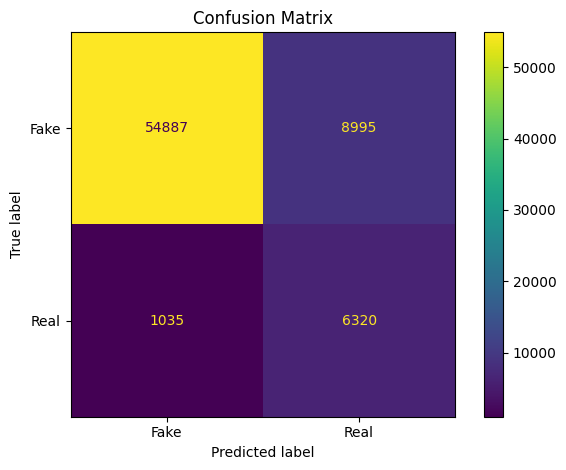

In [29]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, hamming_loss,
    balanced_accuracy_score, accuracy_score
)

# Accuracy
acc = accuracy_score(test_labels, pred_labels)

# F1
f1_macro = f1_score(test_labels, pred_labels, average='macro')
f1_micro = f1_score(test_labels, pred_labels, average='micro')

# Precision / Recall
precision_macro = precision_score(test_labels, pred_labels, average='macro')
precision_micro = precision_score(test_labels, pred_labels, average='micro')
recall_macro = recall_score(test_labels, pred_labels, average='macro')
recall_micro = recall_score(test_labels, pred_labels, average='micro')

# Others
hamming = hamming_loss(test_labels, pred_labels)
balanced_acc = balanced_accuracy_score(test_labels, pred_labels)

# AUC (uses scores, NOT predictions)
auc_score = roc_auc_score(test_labels, test_scores)
print(f"🎯 Final Test EER:  {test_eer * 100:.2f}%")
print(f"📊 Final min-tDCF: {min_tDCF:.4f}")

print("\n===== Classification Metrics =====")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Micro: {precision_micro:.4f}")
print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Micro: {recall_micro:.4f}")
print(f"Hamming Loss: {hamming:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"AUC: {auc_score:.4f}")
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Fake", "Real"])
disp.plot(values_format='d')

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Flops calculations

In [30]:
!pip install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=99d6609d33ce50c7072b232e35b12bbefa4d3715d12e4137a98424ef7db5093a
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=39b39d1e221ebe9a624a3b9ece66788eb0bfe5dbe002a0800c39e455cfec19b0
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [31]:
# --------------------------------------------------------------
#  Model size & FLOPs (place this right after model creation)
# --------------------------------------------------------------
import torch
from torchinfo import summary
from fvcore.nn import FlopCountAnalysis, parameter_count

# --------------------------------------------------------------
# 1. Parameter count (trainable + non-trainable) + size in MiB
# --------------------------------------------------------------
def print_model_params(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    size_mb   = sum(p.numel() * p.element_size() for p in model.parameters()) / (1024**2)

    print("\n" + "="*60)
    print("MODEL PARAMETER SUMMARY")
    print("="*60)
    print(f"{'Trainable params':<25}: {trainable:,}")
    print(f"{'Total params'    :<25}: {total:,}")
    print(f"{'Model size (MiB)':<25}: {size_mb:.2f}")
    print("="*60 + "\n")

print_model_params(model)

# --------------------------------------------------------------
# 2. FLOPs / MACs
# --------------------------------------------------------------
# We need a dummy waveform that matches the shape expected by the model.
#   - Rawformer_S expects raw audio: (batch, time)
#   - Use the maximum length defined in the config (or a typical 4-second clip)
max_len_sec = getattr(exp_cfg, "max_len_sec", 4.0)          # fallback 4 s
max_samples = int(exp_cfg.sample_rate * max_len_sec)

dummy_wav = torch.randn(1, max_samples, device=DEVICE)     # (B, T)

# Apply pre-emphasis if it is used in training/validation
if pre is not None:
    dummy_wav = pre(dummy_wav)

# ---- fvcore (very accurate) ----
flops = FlopCountAnalysis(model, dummy_wav)
macs  = flops.total()                # MACs = multiply-adds
flops_2 = macs * 2                   # FLOPs = 2 × MACs (standard convention)

print("\n" + "="*60)
print("FLOPs / MACs (per forward pass)")
print("="*60)
print(f"{'Input shape'   :<25}: {list(dummy_wav.shape)}")
print(f"{'MACs'          :<25}: {macs/1e9:.3f} G")
print(f"{'FLOPs'         :<25}: {flops_2/1e9:.3f} G")
print("="*60 + "\n")

# ---- torchinfo (nice table, optional) ----
print("Detailed layer-wise breakdown (torchinfo):")
summary(model,
        input_data=dummy_wav,
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        depth=4,
        verbose=0)

Unsupported operator aten::abs encountered 1 time(s)
Unsupported operator aten::max_pool2d encountered 5 time(s)
Unsupported operator aten::selu_ encountered 8 time(s)



MODEL PARAMETER SUMMARY
Trainable params         : 345,132
Total params             : 345,132
Model size (MiB)         : 1.32



Unsupported operator aten::add encountered 17 time(s)
Unsupported operator aten::mul encountered 7 time(s)
Unsupported operator aten::div encountered 6 time(s)
Unsupported operator aten::softmax encountered 3 time(s)
Unsupported operator aten::mean encountered 4 time(s)
Unsupported operator aten::var encountered 4 time(s)
Unsupported operator aten::sub encountered 4 time(s)
Unsupported operator aten::sqrt encountered 4 time(s)
Unsupported operator aten::sigmoid encountered 1 time(s)



FLOPs / MACs (per forward pass)
Input shape              : [1, 64000]
MACs                     : 6.186 G
FLOPs                    : 12.371 G

Detailed layer-wise breakdown (torchinfo):


Layer (type:depth-idx)                                            Input Shape               Output Shape              Param #                   Mult-Adds
DataParallel                                                      [1, 64000]                [1]                       --                        --
├─Rawformer_S: 1-1                                                [1, 64000]                [1]                       345,132                   --
├─Rawformer_S: 1-2                                                --                        --                        --                        --
│    └─Frontend_S: 2-1                                            [1, 64000]                [1, 64, 23, 16]           140,802                   --
│    └─Frontend_S: 2-2                                            --                        --                        --                        --
│    │    └─SincConv: 3-1                                         [1, 1, 64000]             [1, 70, 63872]     

flops per sec of audio

In [32]:
seconds = max_samples / exp_cfg.sample_rate
print(f"GFLOPs per second of audio : {flops_2/1e9/seconds:.3f}")

GFLOPs per second of audio : 3.093
